# KAN for Eco-System Modeling

In [7]:
import torch.nn.functional as F
from sklearn.metrics import r2_score
from matplotlib import pyplot as plt

import pandas as pd

### Data Loading

In [2]:
feature_dict = {
    'temperature': 'TA_F', 
    'VPD': 'VPD_F', 
    'soil moisture': 'SWC_F_MDS_1', 
    'precipitation': 'P_F', 
    'soil temperature': 'TS_F_MDS_1', 
    'shortwave radiation': 'SW_IN_F',
}

In [3]:
import os

directory_path = './data/site_data' # Use '.' for the current directory or specify your path

all_entries = os.listdir(directory_path)

site_files = []
for entry in all_entries:
    root, extension = os.path.splitext(entry)
    full_path = os.path.join(directory_path, entry)
    if extension == ".csv" and  os.path.join(directory_path, entry):
        site_files.append(full_path)

print(f"Files only: {site_files}")

Files only: ['./data/site_data\\mlp_results.csv', './data/site_data\\xBR_clean.csv', './data/site_data\\xDC_clean.csv', './data/site_data\\xDJ_clean.csv', './data/site_data\\xDL_clean.csv', './data/site_data\\xDS_clean.csv', './data/site_data\\xHA_clean.csv', './data/site_data\\xKZ_clean.csv', './data/site_data\\xML_clean.csv', './data/site_data\\xNG_clean.csv', './data/site_data\\xRM_clean.csv', './data/site_data\\xSB_clean.csv', './data/site_data\\xSC_clean.csv', './data/site_data\\xSE_clean.csv', './data/site_data\\xSL_clean.csv', './data/site_data\\xST_clean.csv', './data/site_data\\xTL_clean.csv', './data/site_data\\xTR_clean.csv', './data/site_data\\xUK_clean.csv', './data/site_data\\xUN_clean.csv', './data/site_data\\xWD_clean.csv', './data/site_data\\xWR_clean.csv']


In [8]:
mlp_results = pd.read_csv("data/site_data/mlp_results.csv") 

### Kolmogorov-Arnold representation theorem

Kolmogorov-Arnold representation theorem states that if $f$ is a multivariate continuous function
on a bounded domain, then it can be written as a finite composition of continuous functions of a
single variable and the binary operation of addition. More specifically, for a smooth $f : [0,1]^n \to \mathbb{R}$,


$$f(x) = f(x_1,...,x_n)=\sum_{q=1}^{2n+1}\Phi_q(\sum_{p=1}^n \phi_{q,p}(x_p))$$

where $\phi_{q,p}:[0,1]\to\mathbb{R}$ and $\Phi_q:\mathbb{R}\to\mathbb{R}$. In a sense, they showed that the only true multivariate function is addition, since every other function can be written using univariate functions and sum. However, this 2-Layer width-$(2n+1)$ Kolmogorov-Arnold representation may not be smooth due to its limited expressive power. We augment its expressive power by generalizing it to arbitrary depths and widths.

### Kolmogorov-Arnold Network (KAN)

The Kolmogorov-Arnold representation can be written in matrix form

$$f(x)={\bf \Phi}_{\rm out}\circ{\bf \Phi}_{\rm in}\circ {\bf x}$$

where 

$${\bf \Phi}_{\rm in}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n}(\cdot) \\ \vdots & & \vdots \\ \phi_{2n+1,1}(\cdot) & \cdots & \phi_{2n+1,n}(\cdot) \end{pmatrix},\quad {\bf \Phi}_{\rm out}=\begin{pmatrix} \Phi_1(\cdot) & \cdots & \Phi_{2n+1}(\cdot)\end{pmatrix}$$

We notice that both ${\bf \Phi}_{\rm in}$ and ${\bf \Phi}_{\rm out}$ are special cases of the following function matrix ${\bf \Phi}$ (with $n_{\rm in}$ inputs, and $n_{\rm out}$ outputs), we call a Kolmogorov-Arnold layer:

$${\bf \Phi}= \begin{pmatrix} \phi_{1,1}(\cdot) & \cdots & \phi_{1,n_{\rm in}}(\cdot) \\ \vdots & & \vdots \\ \phi_{n_{\rm out},1}(\cdot) & \cdots & \phi_{n_{\rm out},n_{\rm in}}(\cdot) \end{pmatrix}$$

${\bf \Phi}_{\rm in}$ corresponds to $n_{\rm in}=n, n_{\rm out}=2n+1$, and ${\bf \Phi}_{\rm out}$ corresponds to $n_{\rm in}=2n+1, n_{\rm out}=1$.

After defining the layer, we can construct a Kolmogorov-Arnold network simply by stacking layers! Let's say we have $L$ layers, with the $l^{\rm th}$ layer ${\bf \Phi}_l$ have shape $(n_{l+1}, n_{l})$. Then the whole network is

$${\rm KAN}({\bf x})={\bf \Phi}_{L-1}\circ\cdots \circ{\bf \Phi}_1\circ{\bf \Phi}_0\circ {\bf x}$$

In constrast, a Multi-Layer Perceptron is interleaved by linear layers ${\bf W}_l$ and nonlinearities $\sigma$:

$${\rm MLP}({\bf x})={\bf W}_{L-1}\circ\sigma\circ\cdots\circ {\bf W}_1\circ\sigma\circ {\bf W}_0\circ {\bf x}$$

A KAN can be easily visualized. (1) A KAN is simply stack of KAN layers. (2) Each KAN layer can be visualized as a fully-connected layer, with a 1D function placed on each edge. Let's see an example below.

### Get started with KANs

Initialize KAN

In [10]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
input_dim = len(feature_dict)

cuda


Load dataset

In [11]:
import pandas as pd

df = pd.read_csv("./data/site_data/xST_clean.csv")

features = list(feature_dict.values())
target_col = 'RECO_NT_VUT_REF'

# Drop rows with NaNs in features or target
df_model = df.dropna(subset=features + [target_col, 'year']).copy()

years = sorted(df_model['year'].unique())
print("Years in dataset:", years)

Years in dataset: [2019, 2020, 2021, 2022, 2023, 2024]


In [25]:
yearly_results = {}

for test_year in years:
    print(f"\n=== Fold: Test year = {test_year} ===")

    train_df = df_model[df_model['year'] != test_year]
    test_df  = df_model[df_model['year'] == test_year]

    train_input = torch.DoubleTensor(train_df[features].values)
    train_label = torch.DoubleTensor(np.log(train_df[target_col].values.reshape(-1,1)))

    test_input  = torch.DoubleTensor(test_df[features].values)
    test_label  = torch.DoubleTensor(np.log(test_df[target_col].values.reshape(-1,1)))

    dataset = {
        "train_input":train_input.to(device),
        "train_label":train_label.to(device),
        "test_input":test_input.to(device),
        "test_label":test_label.to(device)
    }

    print(dataset['train_input'].shape, dataset['train_label'].shape)
    print(dataset['test_input'].shape, dataset['test_label'].shape)

    # KAN initialization
    model = KAN(width=[input_dim,2*input_dim+1,1], grid=3, k=3, seed=42, device=device)
    model(dataset['train_input'])

    # train the model
    model.train()
    # model.fit(dataset, opt="LBFGS", steps=100, lamb=0.01, lamb_entropy=10.)
    model.fit(dataset, opt="LBFGS", steps=200, lamb=0.01)
    print(f"KAN visualization for test year {test_year}")
    # model.plot(scale=2.0)
    # plt.show()

    model.eval()
    with torch.no_grad():
        train_pred = model(dataset['train_input']).cpu().numpy().ravel()
        test_pred = model(dataset['test_input']).cpu().numpy().ravel()

        r2_train = r2_score(train_label, train_pred)
        r2_test = r2_score(test_label, test_pred)
    
    print(f"Test year {test_year}: Train R² {r2_train:.3f}, Test R² {r2_test:.3f}")
    
    yearly_results[test_year] = {"train": r2_train, "test": r2_test}


=== Fold: Test year = 2019 ===
torch.Size([69397, 6]) torch.Size([69397, 1])
torch.Size([10234, 6]) torch.Size([10234, 1])
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.48e-01 | test_loss: 3.17e-01 | reg: 4.43e+00 | : 100%|█| 200/200 [15:47<00:00,  4.74


saving model version 0.1
KAN visualization for test year 2019
Test year 2019: Train R² 0.945, Test R² 0.927

=== Fold: Test year = 2020 ===
torch.Size([64680, 6]) torch.Size([64680, 1])
torch.Size([14951, 6]) torch.Size([14951, 1])
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.66e-01 | test_loss: 2.16e-01 | reg: 4.78e+00 | : 100%|█| 200/200 [15:07<00:00,  4.54


saving model version 0.1
KAN visualization for test year 2020
Test year 2020: Train R² 0.939, Test R² 0.955

=== Fold: Test year = 2021 ===
torch.Size([71684, 6]) torch.Size([71684, 1])
torch.Size([7947, 6]) torch.Size([7947, 1])
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
KAN visualization for test year 2022
Test year 2022: Train R² 0.939, Test R² 0.946

=== Fold: Test year = 2023 ===
torch.Size([64965, 6]) torch.Size([64965, 1])
torch.Size([14666, 6]) torch.Size([14666, 1])
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.94e-01 | test_loss: 2.42e-01 | reg: 4.98e+00 | : 100%|█| 200/200 [14:46<00:00,  4.43


saving model version 0.1
KAN visualization for test year 2023
Test year 2023: Train R² 0.928, Test R² 0.934

=== Fold: Test year = 2024 ===
torch.Size([63681, 6]) torch.Size([63681, 1])
torch.Size([15950, 6]) torch.Size([15950, 1])
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.69e-01 | test_loss: 3.38e-01 | reg: 4.79e+00 | : 100%|█| 200/200 [14:47<00:00,  4.44


saving model version 0.1
KAN visualization for test year 2024
Test year 2024: Train R² 0.940, Test R² 0.869


In [23]:
yearly_results

{2019: {'train': 0.9308030065689378, 'test': 0.9377373952554345},
 2020: {'train': 0.9294989401450109, 'test': 0.9521918077444413},
 2021: {'train': 0.9110418885961143, 'test': 0.7261775281773349},
 2022: {'train': 0.9216125126894006, 'test': 0.9161030724154899},
 2023: {'train': 0.9356288820627185, 'test': 0.9364826935249042},
 2024: {'train': 0.938547474265153, 'test': 0.857863997859251}}

In [24]:
avg = []
for r in yearly_results.values():
    avg.append(r["test"])

print(np.mean(avg))

0.887759415829476


In [19]:
yearly_results

{2019: {'train': 0.9250880337672688, 'test': 0.953697188254288},
 2020: {'train': 0.9118860962567364, 'test': 0.926558440192377},
 2021: {'train': 0.9215379840484905, 'test': 0.76825559512125},
 2022: {'train': 0.9128034823319084, 'test': 0.8977774074281183},
 2023: {'train': 0.9186515219514716, 'test': 0.9256266838827207},
 2024: {'train': 0.9240591885527344, 'test': 0.8362977789951108}}

In [20]:
avg = []
for r in yearly_results.values():
    avg.append(r["test"])

print(np.mean(avg))

0.8847021823123109


saving model version 0.2


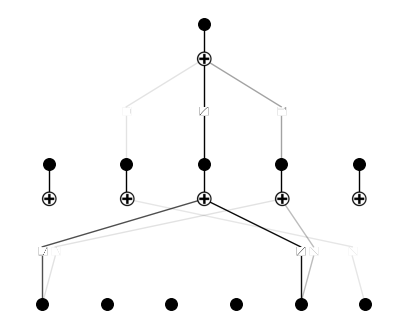

In [23]:
model_prune = model.prune()
model_prune.plot()

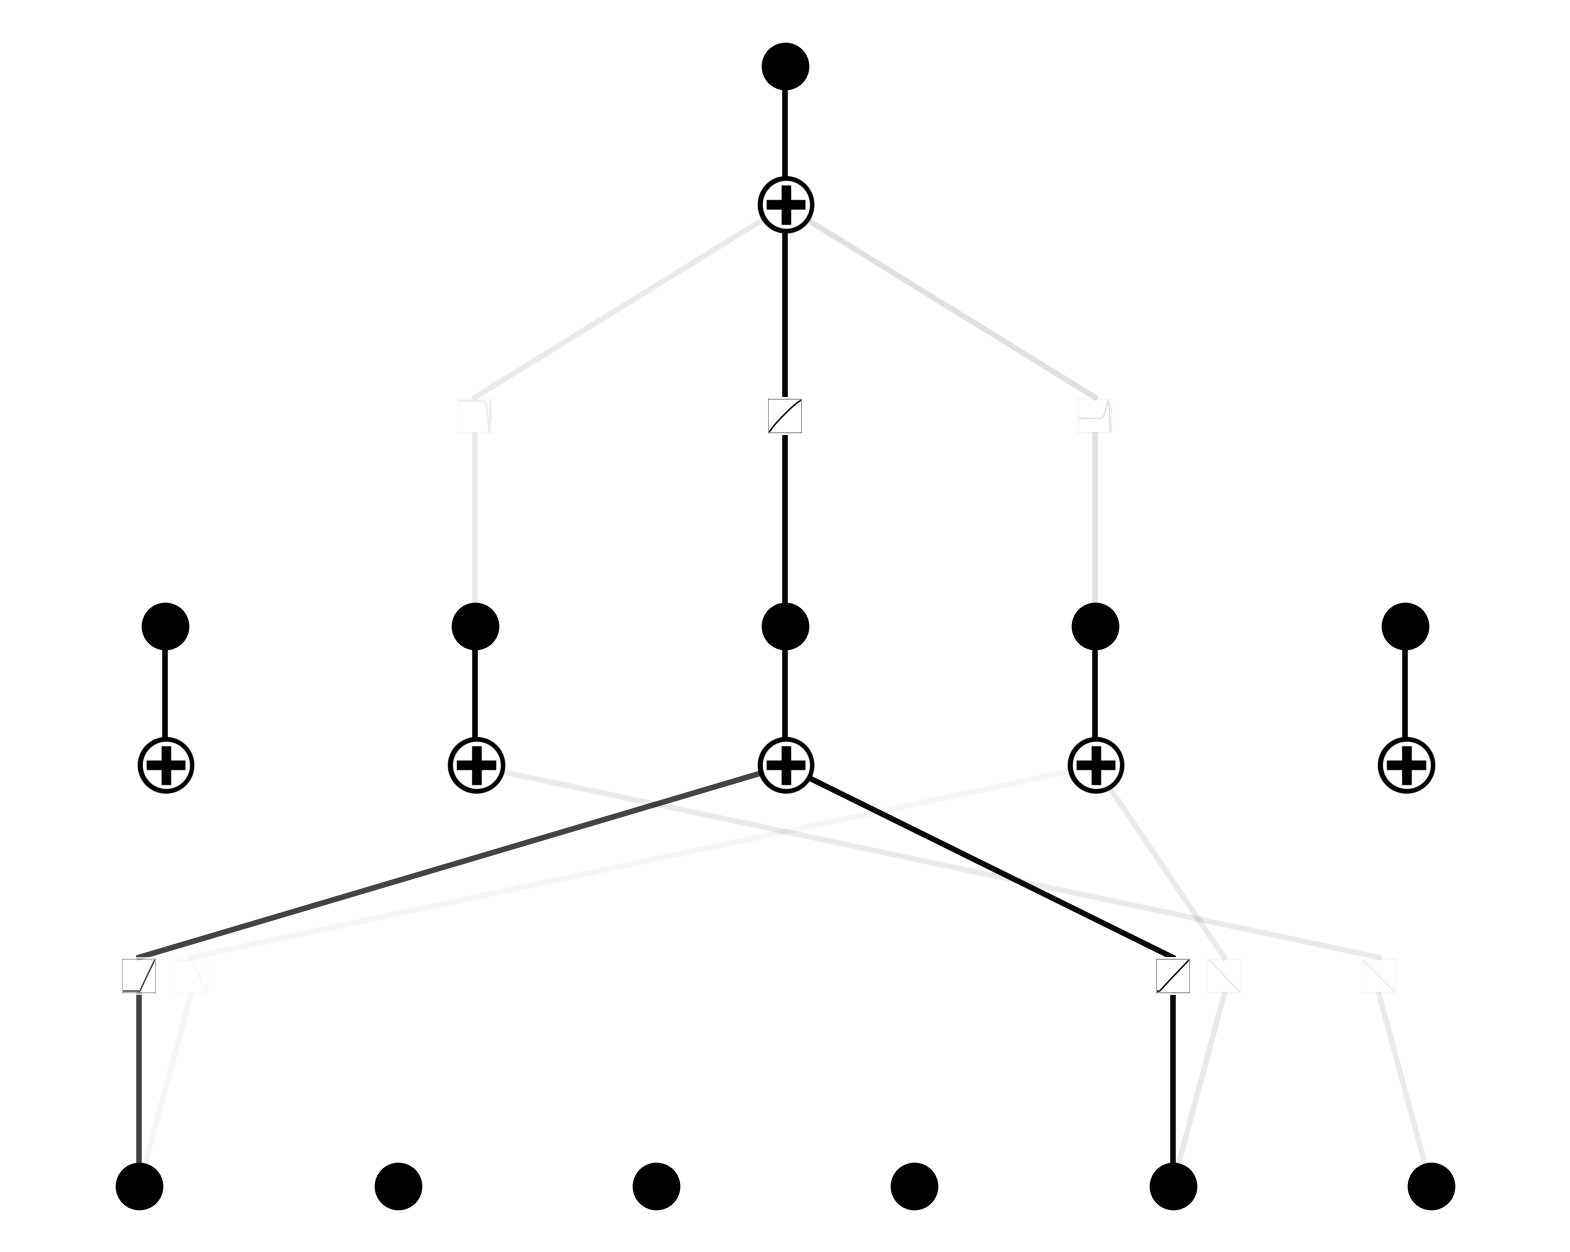

In [25]:
model_prune.plot(scale=2.0)

In [24]:
model_prune.eval()
with torch.no_grad():
    train_pred = model_prune(dataset['train_input']).cpu().numpy().ravel()
    test_pred = model_prune(dataset['test_input']).cpu().numpy().ravel()

    r2_train = r2_score(train_label, train_pred)
    r2_test = r2_score(test_label, test_pred)
    
print(f"Test year {test_year}: Train R² {r2_train:.3f}, Test R² {r2_test:.3f}")

Test year 2019: Train R² 0.727, Test R² 0.810
